In [2]:
!pip install yfinance

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------------- -------------------- 0.8/1.6 MB 2.9 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 3.4 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15702 sha256=86f8d758a8f3328d75e606f54f1e636c52c62e5fb4977c52a61ba1fd1e5d1ec8
  Stored in directory: c:\users\aftab\appdata\local\pip\cache\wheels\1e\df\0f\e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking

   ---------------------------------------- 0/5 [peewee]
 

In [ ]:
1: Problem Statement and Goal

Problem Statement
The goal of this task is to predict the next day’s closing stock price using historical stock market data.

Goal
Using historical data of Amazon stock retrieved through yfinance, a machine learning regression model will be trained to predict the next day's closing price based on features such as Open, High, Low, and Volume.

Dataset Loading and Preprocessing

2: Explanation

The dataset is fetched directly from Yahoo Finance using the yfinance library.
The dataset contains daily stock information including Open, High, Low, Close prices and trading Volume.

Preprocessing steps include:

Selecting relevant columns

Creating a target variable (next day closing price)

Removing missing values.

3: Data Visualization and Exploration

Data visualization helps understand the trend and behavior of the stock price over time.
Plotting the closing price helps observe whether the stock price is increasing or decreasing over time.

It shows:

Closing price trend

Actual vs predicted values

Libraries used

Matplotlib

Pandas

4️: Model Training and Evaluation

A Linear Regression model is used to learn the relationship between the stock features (Open, High, Low, Volume) and the closing price.

The dataset is divided into:

Training data (80%)

Testing data (20%)

The model is evaluated using Mean Squared Error (MSE) to measure prediction accuracy.

Library used : Scikit-learn

5️:Results and Insights

The model successfully learned patterns from the historical stock data and predicted the next day’s closing price.
The predicted values closely follow the actual stock price trend, although some variation exists due to market volatility.

The model demonstrates that historical stock features can help estimate future prices, but stock markets remain highly unpredictable.

[*********************100%***********************]  1 of 1 completed


Mean Squared Error: 11.718460689342118


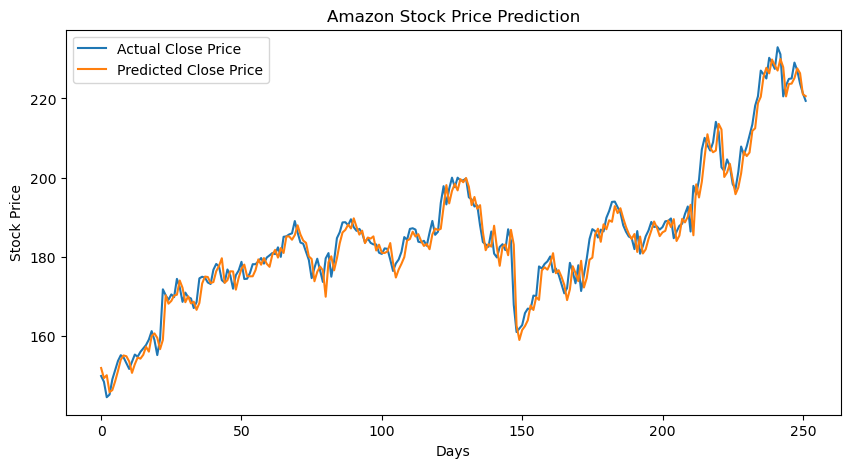

In [5]:
# Import required libraries
import yfinance as yf                # Fetch stock data from Yahoo Finance
import pandas as pd                 # Data handling
import matplotlib.pyplot as plt     # Plotting graphs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Download Amazon stock data
data = yf.download("AMZN", start="2020-01-01", end="2025-01-01")

# Keep useful columns
data = data[['Open', 'High', 'Low', 'Volume', 'Close']]

# Create target column (next day's close price)
data['Next_Close'] = data['Close'].shift(-1)

# Remove last row with missing value
data = data.dropna()

# Features (input variables)
X = data[['Open', 'High', 'Low', 'Volume']]

# Target variable
y = data['Next_Close']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict closing prices
predictions = model.predict(X_test)

# Print error to evaluate model
mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error:", mse)

# Plot actual vs predicted prices
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Close Price")
plt.plot(predictions, label="Predicted Close Price")
plt.title("Amazon Stock Price Prediction")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.legend()
plt.show()